# Телемаркетинг банка: кому звонить, а кому не стоит

Португальский банк обзвонил **45 211 человек**, предлагая срочный вклад.
Согласились **11.70%**. Три четверти времени колл-центра ушло на разговоры,
не закончившиеся продажей.

Данные: [UCI Bank Marketing](https://archive.ics.uci.edu/dataset/222/bank-marketing),
май 2008 - ноябрь 2010, лицензия CC BY 4.0. Обезличены: имена в проекте
сгенерированы, все остальные значения подлинные.

Схема - восемь таблиц и справочников (`sql/01_schema.sql`), расчёты - 30 SQL-запросов
(`sql/04_queries.sql`). Ниже шесть графиков, каждый со своим запросом.

| | |
|---|---|
| Контактов | 45 211 |
| Звонков всего | 124 956 |
| Согласий | 5 289 (11.70%) |
| Время разговоров | 3 242 часа, из них 76% на отказы |

## Подключение

In [1]:
import os
import matplotlib.pyplot as plt
import psycopg2

# Параметры подключения читаются из переменных окружения PostgreSQL,
# пароль в коде не хранится:
# export PGHOST=localhost PGPORT=5432 PGDATABASE=tbank PGUSER=postgres
# export PGPASSWORD=...
conn = psycopg2.connect(
    host=os.getenv("PGHOST", "localhost"),
    port=os.getenv("PGPORT", "5432"),
    dbname=os.getenv("PGDATABASE", "tbank"),
    user=os.getenv("PGUSER", "postgres"),
    password=os.getenv("PGPASSWORD"),
)

ink, muted, grid_color = "#1B2430", "#6B7784", "#E3E7EC"
accent, warn, good, bad = "#1B4B9E", "#A85F22", "#216E4E", "#A33A3A"

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.edgecolor": grid_color,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def q(sql):
    """Выполнить запрос и вернуть список строк."""
    with conn.cursor() as cur:
        cur.execute(sql)
        return cur.fetchall()

print("подключено:", q("select version()")[0][0][:40])

подключено: PostgreSQL 17.10 (Debian 17.10-1.pgdg13+


---
## 1. Отдача падает с каждой попыткой

Итог ограничен шестью: на отдельных номерах группы малы
(79-327 клиентов) и конверсия случайна - на девятой попытке она
даже растёт, что является шумом.

**Вывод.** Первый звонок приносит **48.4%** всех продаж, первые четыре - **92.6%**.
Конверсия падает с 14.60% до 5.81%, отставание хвоста - 8.79 процентного пункта.

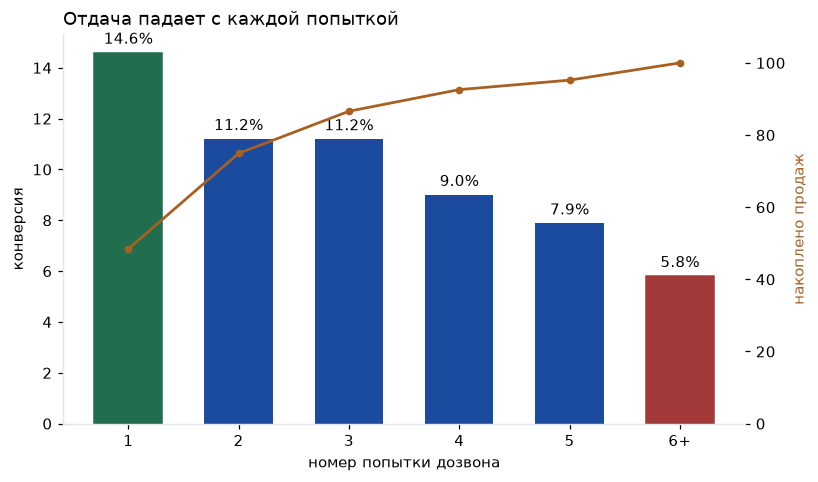

In [2]:
rows = q("""
with table_1 as (
select case when contacts_count >= 6 then 6 else contacts_count end as contacts_count,
count(*) as calls,
sum(case when subscribed then 1 else 0 end) as sub_call
from contacts
group by 1
)
select contacts_count, calls, sub_call,
sub_call * 100.0 / calls as per,
sum(sub_call) over (order by contacts_count) * 100.0
/ sum(sub_call) over () as cum_per
from table_1
order by contacts_count
""")

x = [str(r[0]) if r[0] < 6 else "6+" for r in rows]
per = [float(r[3]) for r in rows]
cum = [float(r[4]) for r in rows]

fig, ax = plt.subplots(figsize=(8, 4.6))
bars = ax.bar(x, per, color=accent, width=0.62)
bars[0].set_color(good)
bars[-1].set_color(bad)
for b, v in zip(bars, per):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.35, f"{v:.1f}%", ha="center")

ax2 = ax.twinx()
ax2.plot(x, cum, color=warn, marker="o", ms=4, lw=1.8)
ax2.set_ylabel("накоплено продаж", color=warn)
ax2.set_ylim(0, 108)

ax.set_ylabel("конверсия")
ax.set_xlabel("номер попытки дозвона")
ax.set_title("Отдача падает с каждой попыткой", loc="left")
plt.show()

---
## 2. Цена ограничения обзвона

Главный расчёт проекта: что будет, если запретить звонить клиенту больше
четырёх раз. `greatest(contacts_count - 4, 0)` обнуляет отрицательные значения
у тех, кому звонили меньше четырёх раз.

Лимит сокращает число попыток,
но не убирает клиентов из обзвона - каждому звонят хотя бы раз.

**Вывод.** Экономия **27 275 звонков (21.8%)** при потери **392 согласий (7.4%)**.
Конверсия снижается с 11.70% до 10.83%. Ресурсная выгода больше чем
потери в выручке.

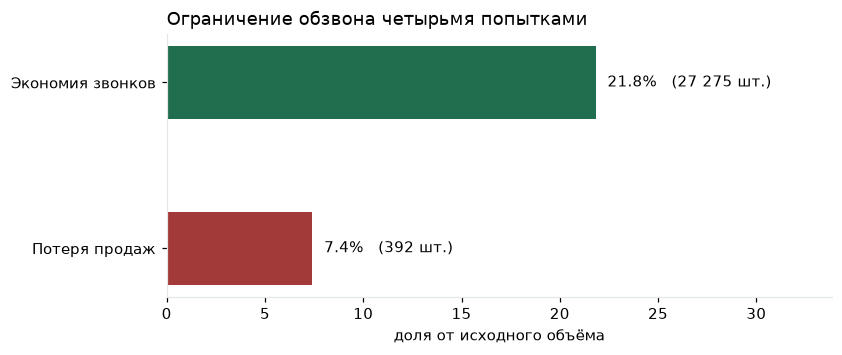

In [3]:
calls, econ, subs, lose = q("""
select sum(contacts_count),
sum(greatest(contacts_count - 4, 0)),
sum(case when subscribed then 1 else 0 end),
sum(case when contacts_count > 4 and subscribed then 1 else 0 end)
from contacts
""")[0]

econ_per = econ * 100.0 / calls
lose_per = lose * 100.0 / subs

fig, ax = plt.subplots(figsize=(7.8, 3.1))
bars = ax.barh(["Экономия звонков", "Потеря продаж"],
               [econ_per, lose_per], color=[good, bad], height=0.44)
for b, v, n in zip(bars, [econ_per, lose_per], [econ, lose]):
    ax.text(v + 0.6, b.get_y() + b.get_height() / 2,
            f"{v:.1f}%   ({n:,} шт.)".replace(",", " "), va="center")
ax.set_xlim(0, max(econ_per, lose_per) * 1.55)
ax.invert_yaxis()
ax.set_xlabel("доля от исходного объёма")
ax.set_title("Ограничение обзвона четырьмя попытками", loc="left")
plt.show()

---
## 3. Возрастные когорты

Когорты собираются через `case` заданным диапазоном возраста.

**Вывод.** Зависимость U-образная: 23.95% в группе 18-25, минимум **9.35%**
в группе 46-55, максимум **42.61%** у клиентов старше 65. Разброс в 4.6 раза.
При этом средний возраст (26-55 лет) - 86% базы и худшая отзывчивость.

Под каждой точкой подписан размер группы: 42.61% стоят всего
на 751 человеке, и на объём такая группа не влияет.

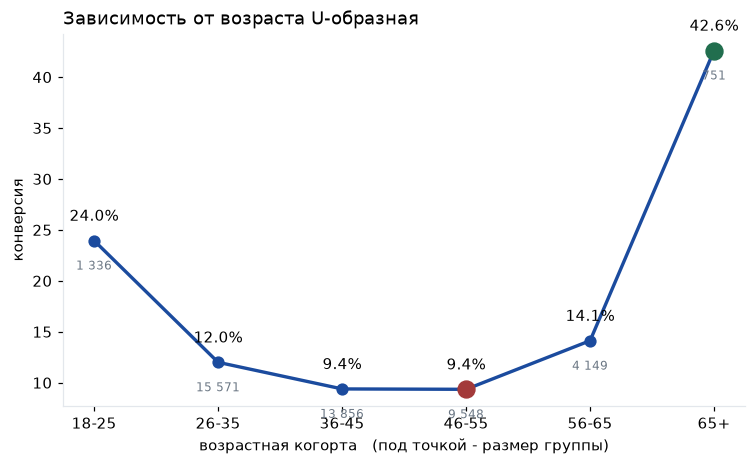

In [4]:
rows = q("""
with age_rank as (
select case when age <= 25 then '18-25' when age <= 35 then '26-35'
when age <= 45 then '36-45' when age <= 55 then '46-55'
when age <= 65 then '56-65' else '65+' end as age_group,
count(*) as q,
sum(case when c.subscribed then 1 else 0 end) as subs
from clients as cl
join contacts as c on c.client_id = cl.client_id
group by 1
)
select age_group, q, subs * 100.0 / q as per from age_rank order by age_group
""")

x, n, per = [r[0] for r in rows], [r[1] for r in rows], [float(r[2]) for r in rows]

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(x, per, color=accent, lw=2.2, marker="o", ms=7)
lo, hi = per.index(min(per)), per.index(max(per))
ax.plot(x[lo], per[lo], "o", ms=11, color=bad)
ax.plot(x[hi], per[hi], "o", ms=11, color=good)
for xi, v, cnt in zip(x, per, n):
    ax.annotate(f"{v:.1f}%", (xi, v), textcoords="offset points",
                xytext=(0, 13), ha="center")
    ax.annotate(f"{cnt:,}".replace(",", " "), (xi, v),
                textcoords="offset points", xytext=(0, -19),
                ha="center", fontsize=8, color=muted)
ax.set_ylabel("конверсия")
ax.set_xlabel("возрастная когорта   (под точкой - размер группы)")
ax.set_title("Зависимость от возраста U-образная", loc="left")
plt.show()

---
## 4. Конверсия и вклад - разные метрики

Синяя полоса - конверсия внутри профессии, оранжевая - доля этой профессии
в общем числе продаж.

**Вывод.** У студентов длинная синяя полоса и короткая оранжевая: конверсия
**28.68%**, а вклад всего 5.09%. У менеджеров наоборот - конверсия 13.76%
при вкладе **24.60%**. Это возникает из-за разницы в размере групп: 938 к 9 458.

Конверсия определяет приоритет обзвона, вклад - где сосредоточен объём.
Заменять их друг другом нельзя. Шесть профессий из двенадцати дают 82.5% продаж.

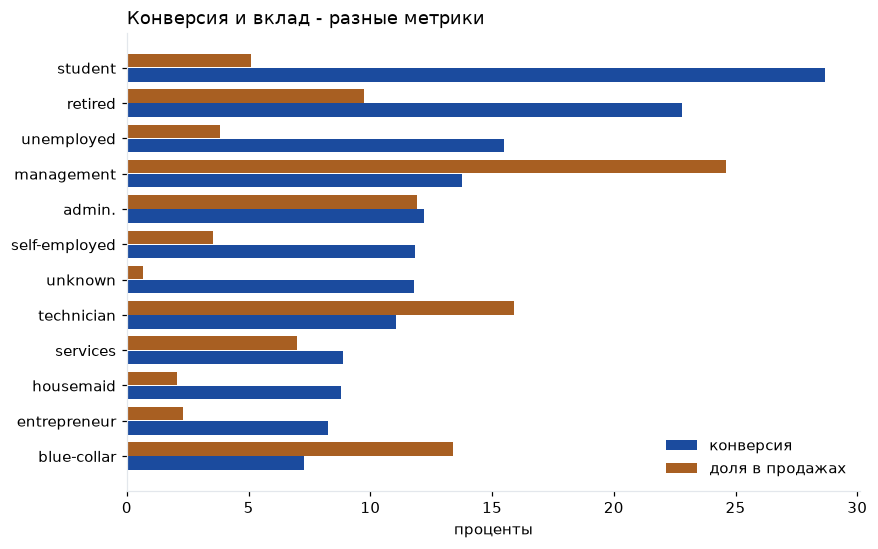

In [5]:
rows = q("""
select job_name,
count(*) as kol,
sum(case when con.subscribed then 1 else 0 end) * 100.0 / count(*) as per,
sum(case when con.subscribed then 1 else 0 end) * 100.0
/ (select count(*) from contacts where subscribed) as share_per
from clients as c
join jobs as j on j.job_id = c.job_id
join contacts as con on c.client_id = con.client_id
group by job_name
order by per desc
""")

names = [r[0] for r in rows]
per = [float(r[2]) for r in rows]
share = [float(r[3]) for r in rows]

fig, ax = plt.subplots(figsize=(8.6, 5.4))
y = range(len(names))
ax.barh([i + 0.2 for i in y], per, height=0.38, color=accent, label="конверсия")
ax.barh([i - 0.2 for i in y], share, height=0.38, color=warn, label="доля в продажах")
ax.set_yticks(list(y)); ax.set_yticklabels(names); ax.invert_yaxis()
ax.set_xlabel("проценты"); ax.legend(frameon=False)
ax.set_title("Конверсия и вклад - разные метрики", loc="left")
plt.show()

---
## 5. Децили по балансу счёта

`ntile(10)` делит клиентов на десять равных по размеру групп. Второй ключ
сортировки необходим, без него при одинаковых балансах строки распределяются
в негарантированном порядке,что привдит к ложной "аномалии", где первая дециль выглядит
отзывчивее второй.

**Вывод.** Конверсия растёт монотонно с **5.09%** до **16.61%**, но на десятой
децили падает до 16.12%. У самых состоятельных клиентов отдача ниже, чем
у просто обеспеченных.

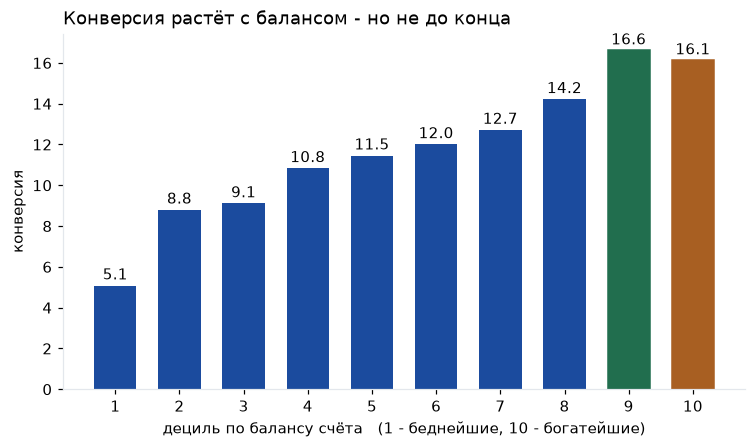

In [6]:
rows = q("""
select d, min(balance) as minimum, max(balance) as maximum,
sum(case when sub then 1 else 0 end) * 100.0 / count(*) as per
from (
select ntile(10) over (order by cl.balance_eur, cl.client_id) as d,
cl.balance_eur as balance, c.subscribed as sub
from clients as cl
join contacts as c on c.client_id = cl.client_id
) as t
group by d order by d
""")

x, per = [str(r[0]) for r in rows], [float(r[3]) for r in rows]

fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.bar(x, per, color=accent, width=0.66)
bars[-2].set_color(good) # девятая дециль - максимум
bars[-1].set_color(warn) # десятая - рост оборвался
for b, v in zip(bars, per):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.3, f"{v:.1f}", ha="center")
ax.set_ylabel("конверсия")
ax.set_xlabel("дециль по балансу счёта   (1 - беднейшие, 10 - богатейшие)")
ax.set_title("Конверсия растёт с балансом - но не до конца", loc="left")
plt.show()

---
## 6. Динамика кампании

Требует восстановленного года: из (`sql/03_restore_year.sql`).

**Вывод.** За два с половиной года объём упал в 10 раз (27 729 звонков
в 2008-м против 2 620 в 2010-м), а конверсия выросла с 5.05% до 51.60%.
Кампания превратилась из массового обзвона в точечный.

Резкие всплески 2008 года являются
шумом. Месяцев 30, потому что сентября 2008 нет.

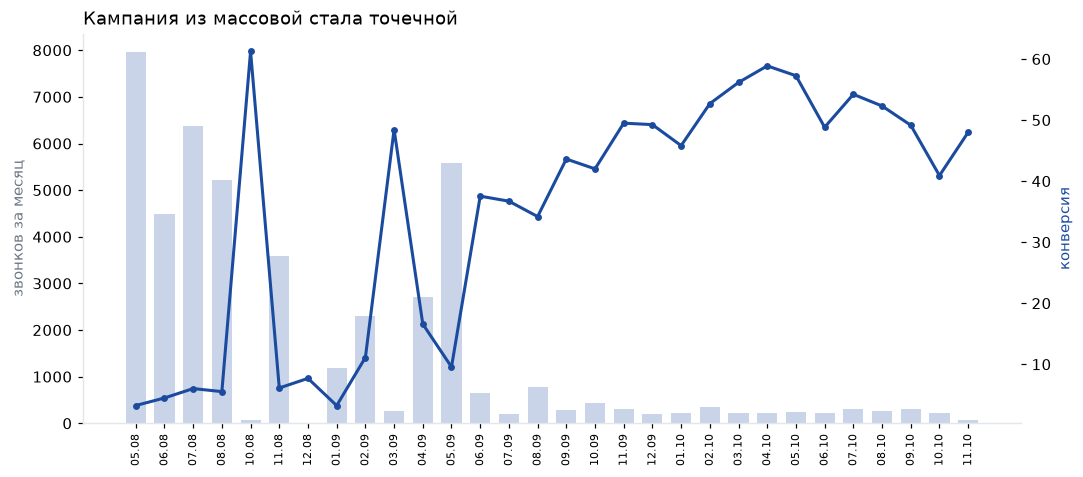

In [7]:
rows = q("""
select contact_year, contact_month, count(*) as q,
sum(case when subscribed then 1 else 0 end) * 100.0 / count(*) as per
from contacts
group by 1, 2
order by 1, 2
""")

lab = [f"{int(r[1]):02d}.{str(int(r[0]))[2:]}" for r in rows]
calls = [int(r[2]) for r in rows]
per = [float(r[3]) for r in rows]

fig, ax = plt.subplots(figsize=(11, 4.6))
ax.bar(lab, calls, color="#C9D4E8", width=0.7) # объём - фоном
ax.set_ylabel("звонков за месяц", color=muted)
ax.tick_params(axis="x", rotation=90, labelsize=7.5)

ax2 = ax.twinx()
ax2.plot(lab, per, color=accent, lw=2, marker="o", ms=3.5)
ax2.set_ylabel("конверсия", color=accent)

ax.set_title("Кампания из массовой стала точечной", loc="left")
plt.show()

---
## Рекомендации колл-центру

1. **Ограничить обзвон четырьмя попытками** - уйдет 21.8% нагрузки при потере
   7.4% продаж
2. **Начинать с клиентов, имеющих историю контактов** - конверсия 23.07%
   к 9.16%. Составляя 18% базы, они дают 36% продаж
3. **Приоритизировать сегмент management / высшее / 26-35** - 3 150 клиентов
   при конверсии 16.00%, единственный крупный среди лидеров
4. **Не строить кампанию на возрасте 46-55** - худшая отзывчивость при
   наибольшем объёме группы

## Ограничения

- **`duration_sec` не используется в выводах** - длительность звонка известна
  только после звонка. 
- **Канал `unknown`** - 13 020 записей (28.8%) - исключён, потому что это
  это пропуск в данных. 
- **Год восстановлен**, а не взят из источника; метод опирается на хронологический порядке строк
- **Проверялась корреляция, не причинность.** Высокая конверсия клиентов
  с историей может объясняться как эффектом повторного контакта, так и тем,
  что банк изначально отбирал для повторного обзвона более склонных
  к согласию или опирался на другие факты не отраженные в данных